# LeetCode #112: Path Sum

https://leetcode.com/problems/path-sum/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS with accumulated sum | O(n) | O(n) | Queue of (node, runningSum) |
| **DFS subtract target ★** | **O(n)** | **O(n)** | Pass remainder; leaf check remainder==0 |

---

## Understanding the Methods

### BFS with Sum
Queue stores (node, running sum). At each leaf, check if running sum equals targetSum. O(n) time and space.

### DFS Subtract Target (Optimal ★)
At each node, subtract its value from the remaining target. At a leaf, if remaining == 0 the path sum equals targetSum. Short-circuits on first match with `||` — no need to explore further once found.

## Constraints
- Number of nodes: [0, 5000]
- Node values: [-1000, 1000]
- targetSum: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    public bool HasPathSum(TreeNode root, int targetSum) {
        if (root == null) return false;
        int rem = targetSum - root.val;
        if (root.left == null && root.right == null) return rem == 0;
        return HasPathSum(root.left, rem) || HasPathSum(root.right, rem);
    }
}

### Python

In [ ]:
class Solution:
    def hasPathSum(self, root, targetSum: int) -> bool:
        if not root: return False
        rem = targetSum - root.val
        if not root.left and not root.right: return rem == 0
        return self.hasPathSum(root.left, rem) or self.hasPathSum(root.right, rem)

### Go

In [ ]:
func hasPathSum(root *TreeNode, targetSum int) bool {
    if root == nil { return false }
    rem := targetSum - root.Val
    if root.Left == nil && root.Right == nil { return rem == 0 }
    return hasPathSum(root.Left, rem) || hasPathSum(root.Right, rem)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn has_path_sum(root: Option<Rc<RefCell<TreeNode>>>, target_sum: i32) -> bool {
        let Some(node) = root else { return false; };
        let rem   = target_sum - node.borrow().val;
        let left  = node.borrow().left.clone();
        let right = node.borrow().right.clone();
        if left.is_none() && right.is_none() { return rem == 0; }
        Self::has_path_sum(left, rem) || Self::has_path_sum(right, rem)
    }
}

## Example Scenarios

### 1. Common Case — Path Exists in Left Subtree
**Input:** `root = [5,4,8,11,null,13,4,7,2,null,null,null,1], targetSum = 22`

DFS path $5 \to 4 \to 11 \to 2$: remainder $22 \to 17 \to 13 \to 2 \to 0$. At leaf node 2, $\text{rem} = 0$ so return `true`. The `||` short-circuits and skips the right subtree.

*Why tricky:* Straightforward happy path. Validates the subtraction approach and early exit via `||`.

**Output:** `true`

### 2. Slightly Complex — Negative Values Create False Near-Matches
**Input:** `root = [1, -2, 3, null, null, -1, null], targetSum = 3`

Path $1 \to -2$: sum $= -1$, rem $= 3 - (-1) = 4 \ne 0$. Path $1 \to 3 \to -1$: sum $= 3$, rem $= 3 - 1 - 3 - (-1) = 0$ at leaf. Subtraction of a negative effectively adds.

*Why tricky:* Negative node values make the remainder oscillate. The DFS subtract approach handles negatives naturally since $\text{rem} - (-v) = \text{rem} + v$.

**Output:** `true`

### 3. Edge Case: Time Factor — 5000-Node Complete Tree, Match at Last Leaf
**Input:** Complete binary tree ($n = 5000$), `targetSum = sum of rightmost root-to-leaf path`

DFS explores left subtrees first. The matching path is the rightmost branch, explored last. All $n = 5000$ nodes are visited before finding the match. No short-circuit benefit.

*Why tricky:* Worst-case time for DFS with `||` short-circuit — the match is in the rightmost branch, explored last in left-first DFS. Full $O(n)$ traversal required.

**Output:** `true`

### 4. Edge Case: Space Factor — 5000-Node Right Chain, No Match
**Input:** `root = [1, null, 2, null, 3, ..., null, 5000], targetSum = 0`

DFS recurses 5000 levels deep (right chain). Stack depth $= O(n) = 5000$. The only leaf has remainder $0 - \sum_{k=1}^{5000} k = -12{,}502{,}500 \ne 0$. All values positive, so $\text{targetSum} = 0$ is impossible.

*Why tricky:* Maximum recursion depth ($n = 5000$). Tests stack space limits. No path can sum to 0 since all values are positive.

**Output:** `false`

### 5. Almost-Impossible but Plausible — All Nodes $-1000$, Near-Miss Decoys
**Input:** Complete tree of 5000 nodes, all `val = -1000`, `targetSum = -13000` (depth-13 path)

Depth-13 leaves: $13 \times (-1000) = -13{,}000 = \text{targetSum} \Rightarrow$ match. Depth-12 leaves: $12 \times (-1000) = -12{,}000 \ne -13{,}000 \Rightarrow$ near-miss decoys. Boundary node values ($-1000$, the minimum allowed).

*Why tricky:* Extreme negative values push sums to $-13{,}000$. The complete tree has leaves at two depths (12 and 13), creating near-miss decoys at depth 12.

**Output:** `true`

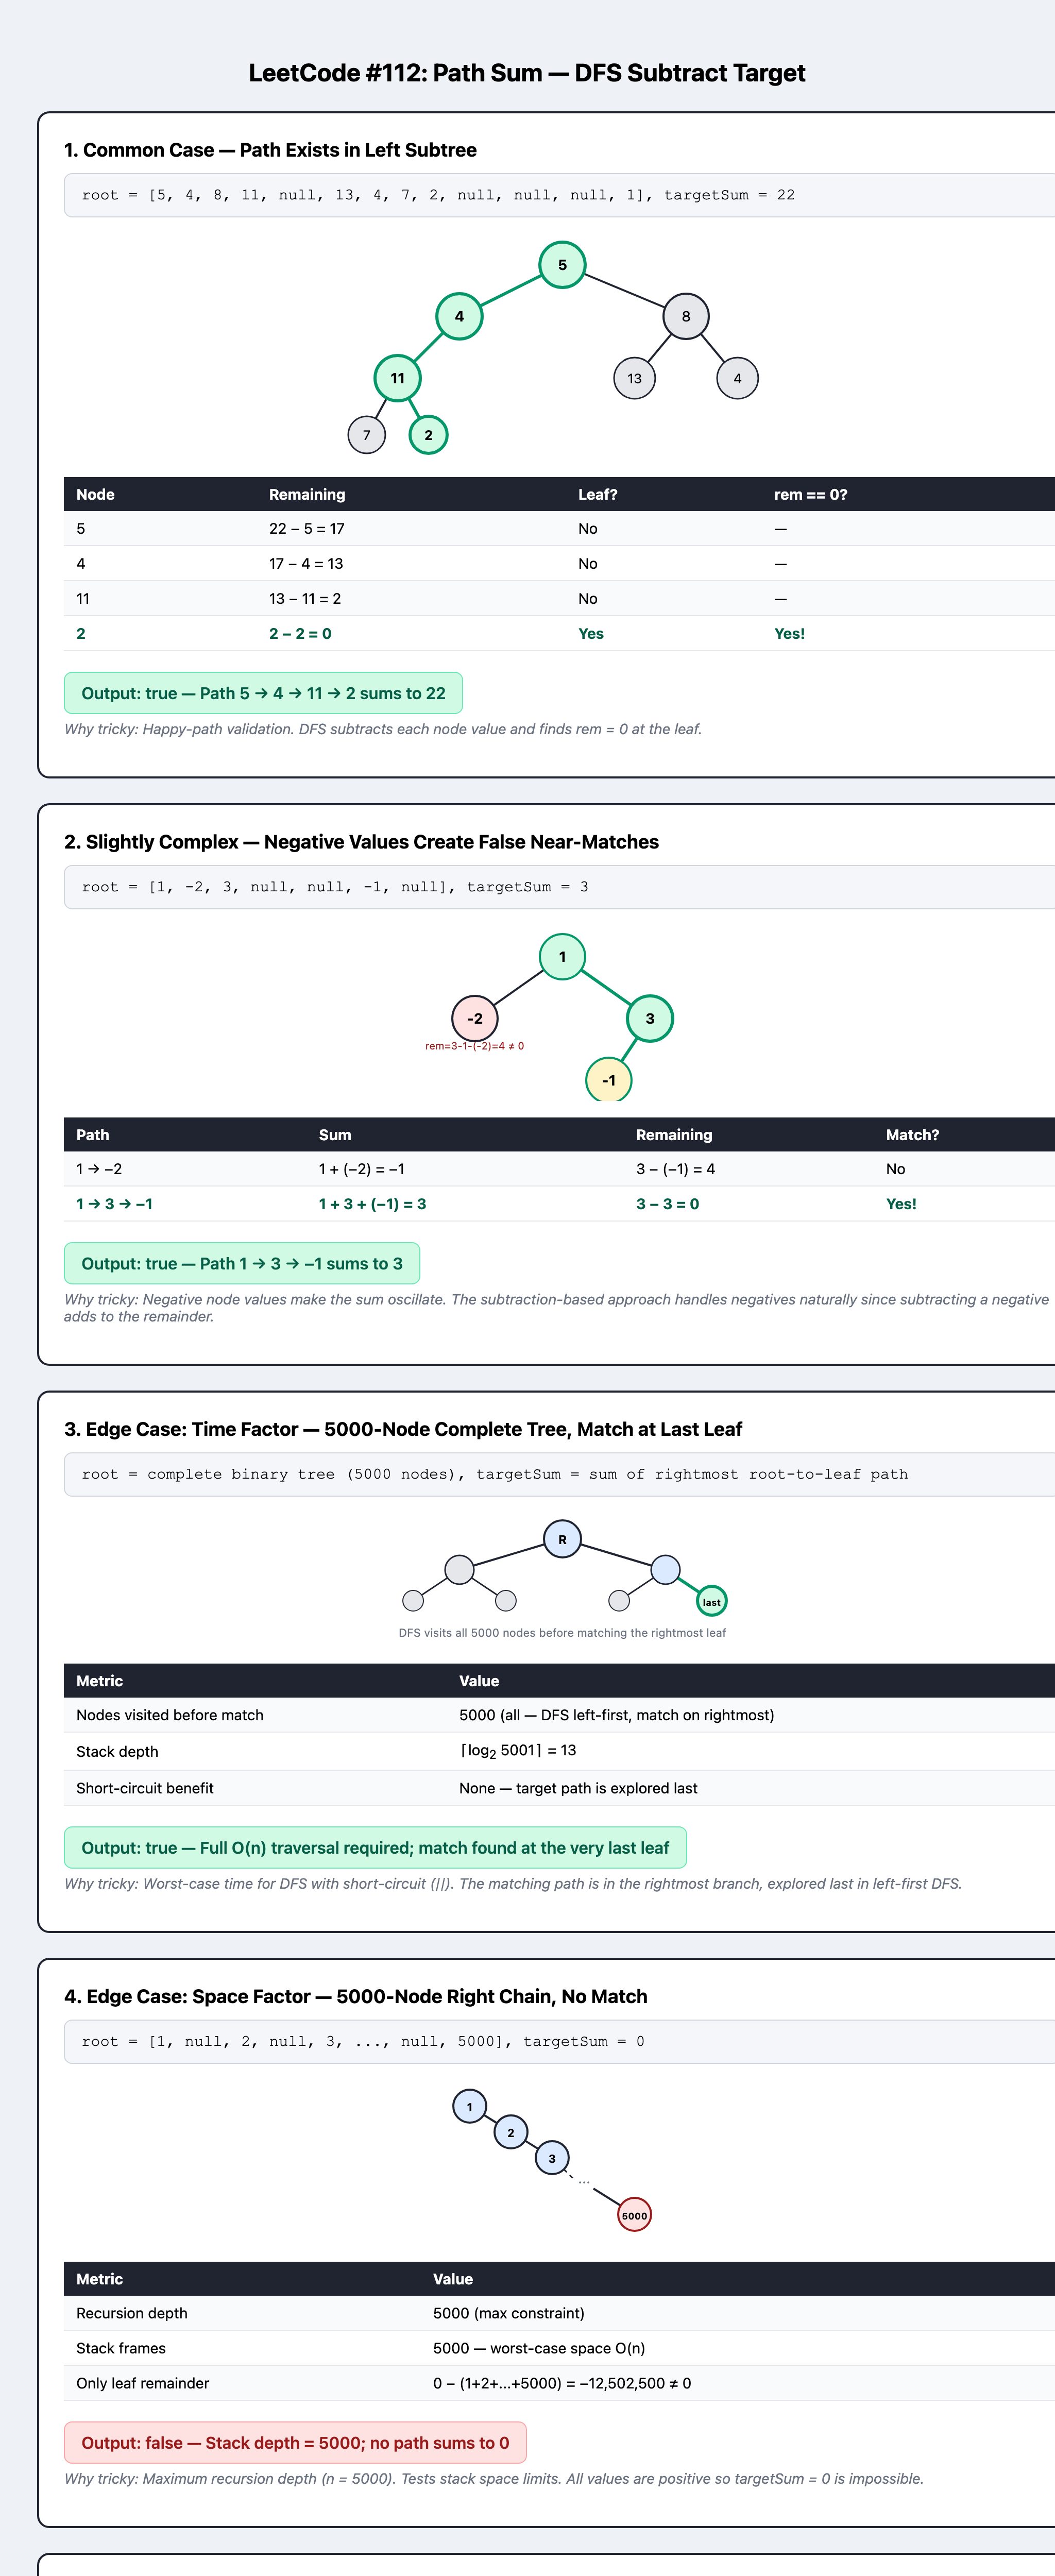